In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans as SklearnKMeans

from src.clustering.kmeans import KMeans as CustomKMeans, KMedians as CustomKMedians

# Dataset 1: blobs with outliers
X_blobs, y_blobs = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

# Add 5 outliers
outliers = np.array([
    [15, 10], [16, 11], [14, 12], [15, 13], [16, 9]
])
X_blobs_outliers = np.vstack([X_blobs, outliers])

# Dataset 2: nested crescents
X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=42)

print(f"Blobs shape: {X_blobs_outliers.shape}")
print(f"Moons shape: {X_moons.shape}")

Blobs shape: (305, 2)
Moons shape: (300, 2)


In [2]:
def run_and_plot_clustering(models_dict, X, title_prefix=""):
    n_models = len(models_dict)
    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
    
    if n_models == 1:
        axes = [axes]
        
    print(f"{'='*50}\nBenchmark: {title_prefix}\n{'='*50}")
    
    for ax, (name, model) in zip(axes, models_dict.items()):
        start_time = time.perf_counter()
        
        # Run clustering
        if hasattr(model, 'fit_predict'):
            labels = model.fit_predict(X)
        else:
            model.fit(X)
            labels = model.predict(X)
            
        elapsed_time = time.perf_counter() - start_time
        
        print(f"{name:<20} | Time: {elapsed_time:.5f} sec")
        
        # Draw dots
        ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30, alpha=0.7, edgecolor='k')
        
        # Draw centroids if any
        if hasattr(model, 'cluster_centers_'):
            centers = model.cluster_centers_
            ax.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='Centroids')
        elif hasattr(model, 'centroids') and model.centroids is not None:
            centers = model.centroids
            ax.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='Centroids')
            
        ax.set_title(f"{name}\n({elapsed_time:.4f}s)")
        if hasattr(model, 'centroids') or hasattr(model, 'cluster_centers_'):
            ax.legend()
        ax.grid(True, linestyle=':', alpha=0.6)
        
    plt.tight_layout()
    plt.show()

Benchmark: Spherical blobs with outliers
Sklearn K-Means      | Time: 1.38787 sec
Custom K-Means       | Time: 0.00075 sec
Custom K-Medians     | Time: 0.00091 sec


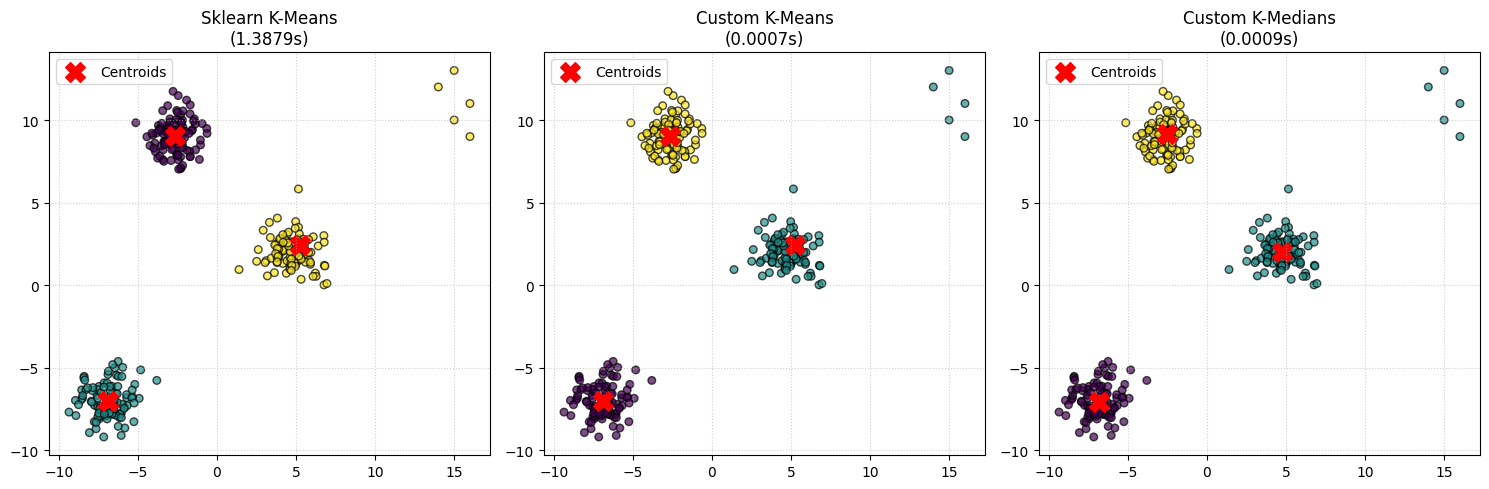

Benchmark: Nested crescents
Sklearn K-Means      | Time: 0.02585 sec
Custom K-Means       | Time: 0.00122 sec
Custom K-Medians     | Time: 0.00342 sec


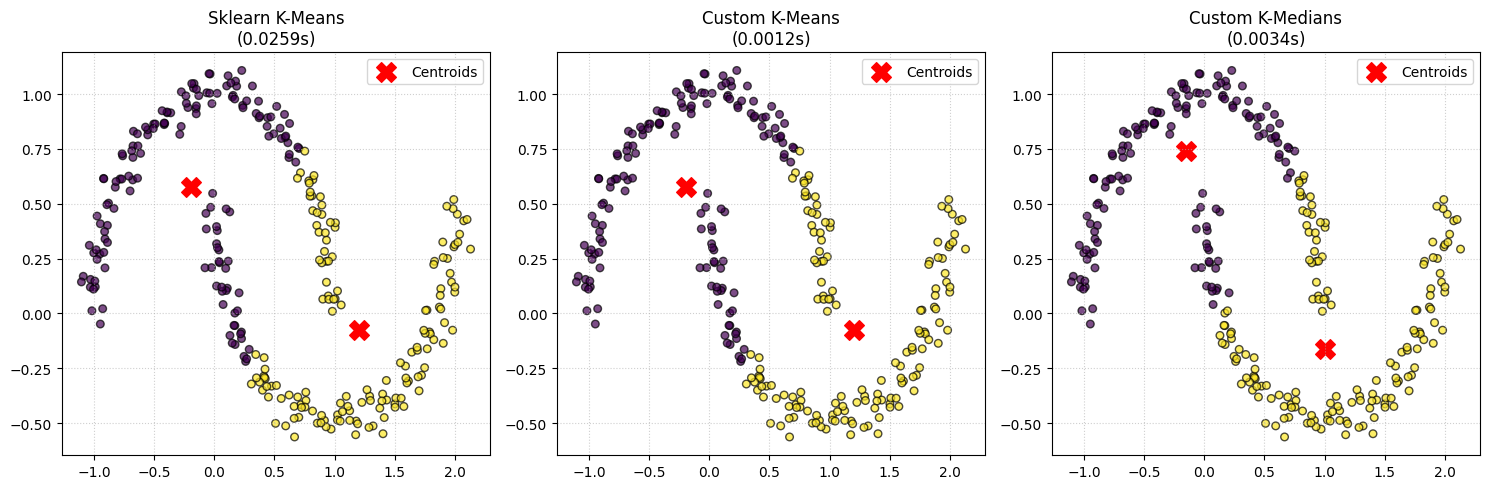

In [3]:
# Test on sperical blobs with outliers
models_blobs = {
    "Sklearn K-Means": SklearnKMeans(n_clusters=3, random_state=42, n_init=10),
    "Custom K-Means": CustomKMeans(n_clusters=3, random_state=42),
    "Custom K-Medians": CustomKMedians(n_clusters=3, random_state=42)
}

run_and_plot_clustering(models_blobs, X_blobs_outliers, title_prefix="Spherical blobs with outliers")

# Test on nested crescents
models_moons = {
    "Sklearn K-Means": SklearnKMeans(n_clusters=2, random_state=42, n_init=10),
    "Custom K-Means": CustomKMeans(n_clusters=2, random_state=42),
    "Custom K-Medians": CustomKMedians(n_clusters=2, random_state=42)
}

run_and_plot_clustering(models_moons, X_moons, title_prefix="Nested crescents")

Benchmark: Ierarchical (Nearest Neighbor Clustering)
Sklearn Hierarchical | Time: 0.02824 sec
Custom Hierarchical  | Time: 0.06360 sec


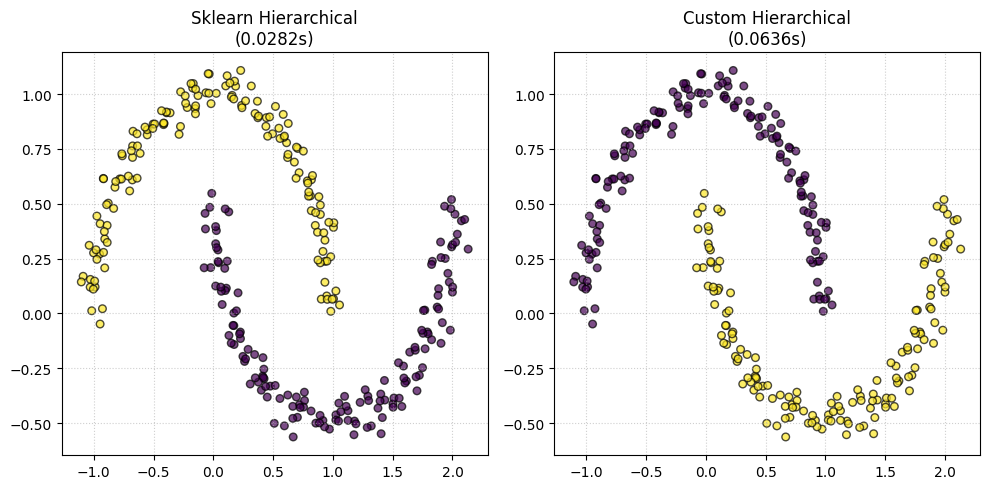

Benchmark: DBSCAN (Based on density)
Sklearn DBSCAN       | Time: 0.00401 sec
Custom DBSCAN        | Time: 0.00659 sec


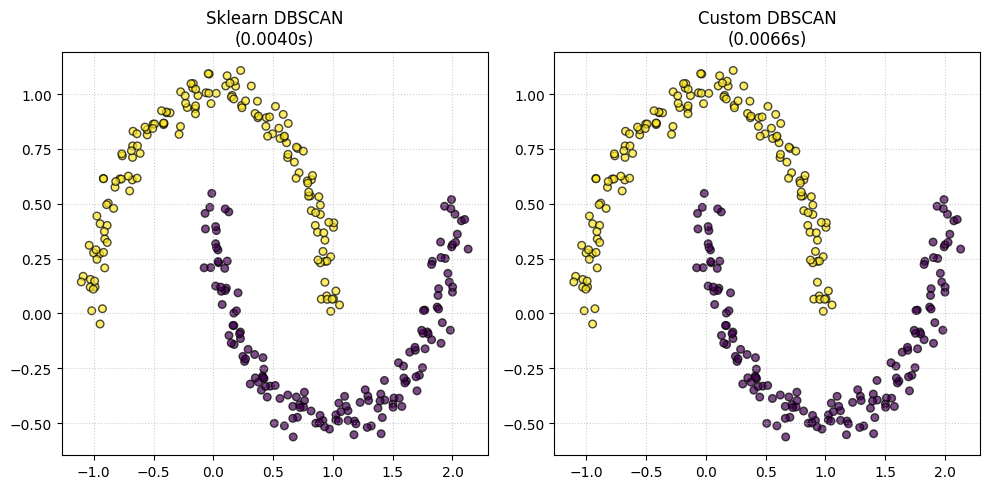

In [4]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN as SklearnDBSCAN
from src.clustering.hierarchical import HierarchicalClustering
from src.clustering.dbscan import CustomDBSCAN

# Test on non-linear data
models_hierarchical = {
    # Single linkage = nearest neighbor clustering
    "Sklearn Hierarchical": AgglomerativeClustering(n_clusters=2, linkage='single'),
    "Custom Hierarchical": HierarchicalClustering(n_clusters=2)
}

run_and_plot_clustering(models_hierarchical, X_moons, title_prefix="Ierarchical (Nearest Neighbor Clustering)")

# Test DBSCAN on non-linear data
# Hyperprameters eps=0.2 and min_samples=5
models_dbscan = {
    "Sklearn DBSCAN": SklearnDBSCAN(eps=0.2, min_samples=5),
    "Custom DBSCAN": CustomDBSCAN(eps=0.2, min_samples=5)
}

run_and_plot_clustering(models_dbscan, X_moons, title_prefix="DBSCAN (Based on density)")

Benchmark: Selection of eps value for DBSCAN
DBSCAN (eps=0.05)    | Time: 0.00323 sec
DBSCAN (eps=0.2)     | Time: 0.00201 sec
DBSCAN (eps=0.5)     | Time: 0.00221 sec


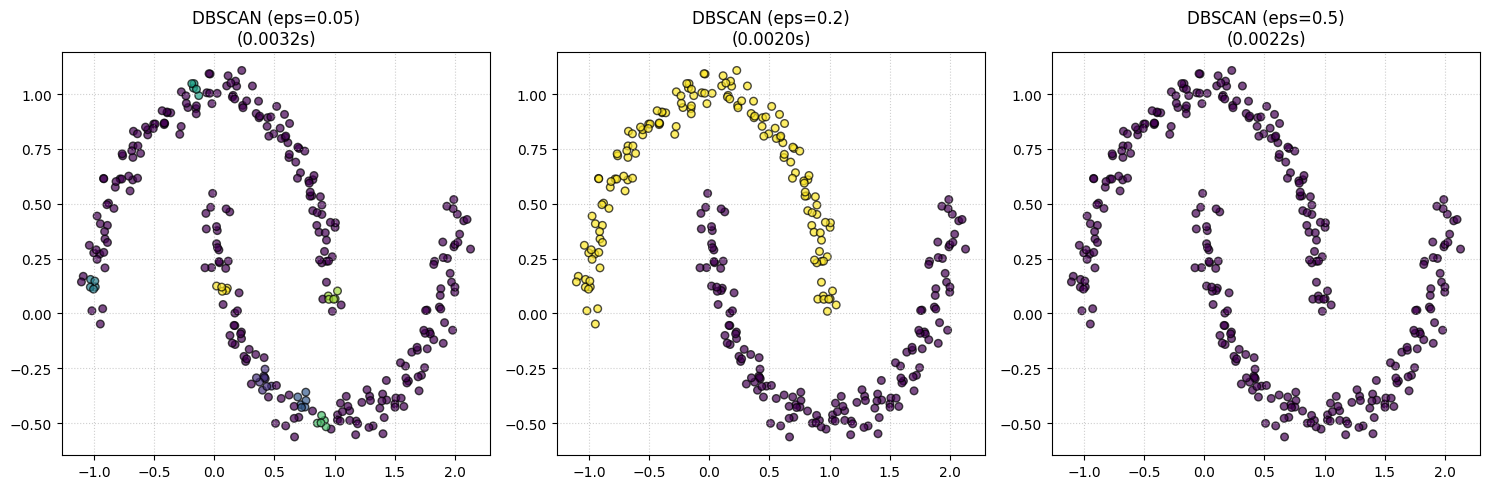

In [5]:
# Test with different eps values for DBSCAN
eps_values = [0.05, 0.2, 0.5]
models_dbscan_tuning = {}

for e in eps_values:
    name = f"DBSCAN (eps={e})"
    models_dbscan_tuning[name] = SklearnDBSCAN(eps=e, min_samples=5)

run_and_plot_clustering(models_dbscan_tuning, X_moons, title_prefix="Selection of eps value for DBSCAN")